# Feature Engineering & Data Analysis

**Continuing from:** `exploring_cleaning_data.ipynb` — this notebook picks up once the data is *clean*, and turns it into something that can actually answer business questions.

## Why this phase exists

Cleaning makes data **correct** — no missing values, no duplicates, the right dtypes. That's necessary, but it's not the same as data being **useful**. A clean `Order Date` column doesn't tell you whether Mondays sell more than Fridays; a clean `Sales`/`Profit` pair doesn't tell you which customers are actually worth the most. Feature engineering is the step where we *derive* new columns that carry that signal explicitly, and data analysis is the step where we use those columns (plus the originals) to actually answer questions.

Skipping straight from cleaning to charts is a common shortcut — and it produces charts that answer questions nobody asked, because the underlying features were never designed around a question in the first place. This notebook keeps the two steps in order: **know the question → build the feature that answers it → analyze it.**

## The Generic Workflow

This is the same repeatable process regardless of the dataset — the checklist we'll apply to the Superstore data in Part 2 below.

0. **Setup & Recap** — load the cleaned data, confirm it survived the handoff intact.
1. **Define the Analysis Questions** — write down what we're trying to answer *before* building features, so every feature has a reason to exist.
2. **Feature Engineering — Derived Columns** — transform existing columns (dates, numeric ratios, categorical cleanup) into new per-row signal.
3. **Feature Engineering — Aggregated Features** — roll row-level data up into entity-level features (per customer, per product, etc.).
4. **Feature Validation** — sanity-check every new feature immediately: nulls introduced by the transform, implausible ranges, divide-by-zero.
5. **Exploratory Data Analysis** — univariate → bivariate → multivariate, in that order.
6. **Answering the Questions** — go back to Step 1 and directly resolve each question with a specific table or aggregation.
7. **Insight Synthesis** — summarize findings in plain language, including caveats inherited from cleaning decisions.
8. **Handoff Prep** — name and preserve the tables/features the next stage (visualization) will need.

## Part 2 — Applying the Workflow to the Superstore Dataset

From here on, every section is Part 2: the same nine steps, made concrete for `Sample-Superstore2019.csv`.

> **Note on notebooks and kernels:** this notebook does **not** share memory with `exploring_cleaning_data.ipynb` — each `.ipynb` file runs its own kernel. Step 0 below re-loads the raw CSV and re-applies the cleaning decisions already validated there, rather than assuming `df` already exists. This keeps the notebook runnable on its own.

### Step 0 — Setup & Recap

We re-establish the clean baseline before building anything new. Nothing new is decided here, we're just reproducing what the cleaning notebook already validated:

- Drop `Unnamed: 0` and `Row ID` (load artifacts, not data)
- Convert `Order Date` / `Ship Date` to real `datetime`
- Fill the 11 missing `Postal Code` values (all Burlington, VT) with `05401`
- Convert low-cardinality text columns to `category`
- Drop the single true exact-duplicate row

One deliberate omission: the 7 `Order ID` + `Product ID` pairs that share a combination but have different `Quantity`/`Sales` are **not** collapsed. Investigation in the cleaning notebook showed each pair has matching unit price and unit profit — they're legitimate separate order lines, not data-entry errors, and dropping either row would silently discard real revenue.

In [207]:
# Importing the proper and required data packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow

In [208]:
# Reading the clean data and make a copy of the original file to be the single source of truth
df = pd.read_parquet("Sample_Superstore_2019_Clean.parquet", engine="pyarrow")
df.shape

(9993, 20)

In [209]:
df.duplicated().sum()

np.int64(0)

In [210]:
df.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [211]:
# Creating the copy of the original DataFrame
df_clean = df.copy()
df_clean.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9993 non-null   str           
 1   Order Date      9993 non-null   datetime64[us]
 2   Ship Date       9993 non-null   datetime64[us]
 3   Ship Mode       9993 non-null   category      
 4   Customer ID     9993 non-null   str           
 5   Customer Name   9993 non-null   str           
 6   Segment         9993 non-null   category      
 7   Country/Region  9993 non-null   category      
 8   City            9993 non-null   str           
 9   State           9993 non-null   category      
 10  Postal Code     9993 non-null   str           
 11  Region          9993 non-null   category      
 12  Product ID      9993 non-null   str           
 13  Category        9993 non-null   category      
 14  Sub-Category    9993 non-null   category      
 15  Product Name   

In [212]:
df_clean.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

### Step 1 — Define the Analysis Questions

These are the questions the rest of this notebook is built to answer. Every feature engineered in Steps 2–3 exists to serve at least one of these:

1. Which `State` generates the most total `Profit`, and which generates the biggest total loss?
2. Is there a relationship between `Discount` and `Profit`?
3. Does `Ship Mode` relate to profitability or shipping time?
4. Is there seasonality in `Sales` — by month, or by day of week?
5. Who are the most valuable customers, and how would we segment them?

Step 6 will come back to this exact list and answer each one directly.

### Step 2 — Feature Engineering: Derived Columns

Two families of per-row features, built directly from existing columns:

- **Date-based**, from `Order Date` / `Ship Date`: how long shipping took, and what calendar pattern the order falls into (weekday, month, quarter, year, weekend flag) — needed to test the seasonality question (Q4).
- **Numeric transforms**, from `Sales` / `Quantity` / `Discount`: a per-unit price, a profit-margin ratio, and a discount bucket — needed to test the discount question (Q2).

In [213]:
df_clean["Order Month"] = df_clean["Order Date"].dt.month_name()

In [214]:
# This is the function code for sorting the values by month
def order_by_month(data):
    """Return a calendar-ordered monthly frequency series.

    This helper accepts a Series containing month names such as
    ``"January"`` ... ``"December"``. It counts how often each month
    appears in the data and then re-indexes the result against the standard
    calendar order so the output stays readable and predictable for charts
    and reporting.
    """
    month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"]
    ordered_data = data.value_counts().reindex(month_order)

    return ordered_data
    

In [215]:
print(order_by_month(df_clean["Order Month"]))

Order Month
January       381
February      300
March         696
April         667
May           735
June          717
July          710
August        706
September    1383
October       819
November     1471
December     1408
Name: count, dtype: int64


In [216]:
df_clean[["Order Date", "Ship Date"]]

,Order Date,Ship Date
0,2018-11-08,2018-11-11
1,2018-11-08,2018-11-11
2,2018-06-12,2018-06-16
3,2017-10-11,2017-10-18
4,2017-10-11,2017-10-18
...,...,...
9988,2016-01-21,2016-01-23
9989,2019-02-26,2019-03-03
9990,2019-02-26,2019-03-03
9991,2019-02-26,2019-03-03


In [217]:
df_clean["Shipping Days"] = (df_clean["Ship Date"] - df_clean["Order Date"]).dt.days

In [218]:
df_clean["Shipping Days"].mean()

np.float64(3.9580706494546183)

In [219]:
df_clean["Order Date"]

0      2018-11-08
1      2018-11-08
2      2018-06-12
3      2017-10-11
4      2017-10-11
          ...    
9988   2016-01-21
9989   2019-02-26
9990   2019-02-26
9991   2019-02-26
9992   2019-05-04
Name: Order Date, Length: 9993, dtype: datetime64[us]

In [220]:
df_clean["Order Date"].dt.day_name()

0        Thursday
1        Thursday
2         Tuesday
3       Wednesday
4       Wednesday
          ...    
9988     Thursday
9989      Tuesday
9990      Tuesday
9991      Tuesday
9992     Saturday
Name: Order Date, Length: 9993, dtype: str

In [221]:
df_clean["Shipping Days"] = (df_clean["Ship Date"] - df_clean["Order Date"]).dt.days
df_clean.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Shipping Days
0,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Fur-Bo-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November,3
1,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Fur-Ch-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November,3
2,Ca-2018-138688,2018-06-12,2018-06-16,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Off-La-10000240,Office Supplies,Labels,Self-Adhesive Address Labels For Typewriters B...,14.6200,2,0.00,6.8714,June,4
3,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Fur-Ta-10000577,Furniture,Tables,Bretford Cr4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October,7
4,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Off-St-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October,7


In [222]:

df_clean["Order Weekday"] = df_clean["Order Date"].dt.day_name()
# df_clean["Order Month"] = df_clean["Order Date"].dt.month
df_clean["Order Quarter"] = df_clean["Order Date"].dt.quarter
df_clean["Order Year"] = df_clean["Order Date"].dt.year

In [223]:
df_clean.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Product Name,Sales,Quantity,Discount,Profit,Order Month,Shipping Days,Order Weekday,Order Quarter,Order Year
0,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November,3,Thursday,4,2018
1,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November,3,Thursday,4,2018
2,Ca-2018-138688,2018-06-12,2018-06-16,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Self-Adhesive Address Labels For Typewriters B...,14.6200,2,0.00,6.8714,June,4,Tuesday,2,2018
3,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Bretford Cr4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October,7,Wednesday,4,2017
4,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October,7,Wednesday,4,2017


In [224]:
df_clean["IS Weekend"] = df_clean["Order Date"].dt.day_of_week >= 5
df_clean.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Sales,Quantity,Discount,Profit,Order Month,Shipping Days,Order Weekday,Order Quarter,Order Year,IS Weekend
0,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,261.9600,2,0.00,41.9136,November,3,Thursday,4,2018,False
1,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,731.9400,3,0.00,219.5820,November,3,Thursday,4,2018,False
2,Ca-2018-138688,2018-06-12,2018-06-16,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,14.6200,2,0.00,6.8714,June,4,Tuesday,2,2018,False
3,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,957.5775,5,0.45,-383.0310,October,7,Wednesday,4,2017,False
4,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,22.3680,2,0.20,2.5164,October,7,Wednesday,4,2017,False


In [225]:
# Create new column
# month_name
# week_day_name
# is_weekend

In [226]:
df_clean["IS Weekend"].value_counts()

IS Weekend
False    7257
True     2736
Name: count, dtype: int64

In [227]:
df_clean.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Sales,Quantity,Discount,Profit,Order Month,Shipping Days,Order Weekday,Order Quarter,Order Year,IS Weekend
0,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,261.9600,2,0.00,41.9136,November,3,Thursday,4,2018,False
1,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,731.9400,3,0.00,219.5820,November,3,Thursday,4,2018,False
2,Ca-2018-138688,2018-06-12,2018-06-16,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,14.6200,2,0.00,6.8714,June,4,Tuesday,2,2018,False
3,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,957.5775,5,0.45,-383.0310,October,7,Wednesday,4,2017,False
4,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,22.3680,2,0.20,2.5164,October,7,Wednesday,4,2017,False


In [228]:
print(df_clean["Order Date"].dt.day_of_week, df_clean["Order Date"].dt.day_name())

0       3
1       3
2       1
3       2
4       2
       ..
9988    3
9989    1
9990    1
9991    1
9992    5
Name: Order Date, Length: 9993, dtype: int32 0        Thursday
1        Thursday
2         Tuesday
3       Wednesday
4       Wednesday
          ...    
9988     Thursday
9989      Tuesday
9990      Tuesday
9991      Tuesday
9992     Saturday
Name: Order Date, Length: 9993, dtype: str


In [229]:
df_clean["Order Date"].dt.dayofweek

0       3
1       3
2       1
3       2
4       2
       ..
9988    3
9989    1
9990    1
9991    1
9992    5
Name: Order Date, Length: 9993, dtype: int32

In [230]:

df_clean["Is Weekend"] = df_clean["Order Date"].dt.dayofweek >= 5

df_clean[["Order Date", "Ship Date", "Shipping Days", "Order Weekday", "Sales", "Is Weekend"]].head(50)

,Order Date,Ship Date,Shipping Days,Order Weekday,Sales,Is Weekend
0,2018-11-08,2018-11-11,3,Thursday,261.9600,False
1,2018-11-08,2018-11-11,3,Thursday,731.9400,False
2,2018-06-12,2018-06-16,4,Tuesday,14.6200,False
3,2017-10-11,2017-10-18,7,Wednesday,957.5775,False
4,2017-10-11,2017-10-18,7,Wednesday,22.3680,False
5,2016-06-09,2016-06-14,5,Thursday,48.8600,False
6,2016-06-09,2016-06-14,5,Thursday,7.2800,False
7,2016-06-09,2016-06-14,5,Thursday,907.1520,False
8,2016-06-09,2016-06-14,5,Thursday,18.5040,False
9,2016-06-09,2016-06-14,5,Thursday,114.9000,False


In [231]:
weekend_sales_test = df_clean.groupby("Is Weekend").agg(
    total_sales = ("Profit", "mean")
)
weekend_sales_test

,total_sales
Is Weekend,
False,28.974414
True,27.829590


In [232]:
df_clean["Is Weekend"].value_counts()

Is Weekend
False    7257
True     2736
Name: count, dtype: int64

In [233]:
# Numeric transforms -- needed for the discount question (Q2)
df_clean["Unit Price"] = df_clean["Sales"] / df_clean["Quantity"]
df_clean["Profit Margin"] = (df_clean["Profit"] / df_clean["Sales"])*100
df_clean[["Product ID", "Sales", "Unit Price", "Profit Margin"]]

,Product ID,Sales,Unit Price,Profit Margin
0,Fur-Bo-10001798,261.9600,130.9800,16.00
1,Fur-Ch-10000454,731.9400,243.9800,30.00
2,Off-La-10000240,14.6200,7.3100,47.00
3,Fur-Ta-10000577,957.5775,191.5155,-40.00
4,Off-St-10000760,22.3680,11.1840,11.25
...,...,...,...,...
9988,Fur-Fu-10001889,25.2480,8.4160,16.25
9989,Fur-Fu-10000747,91.9600,45.9800,17.00
9990,Tec-Ph-10003645,258.5760,129.2880,7.50
9991,Off-Pa-10004041,29.6000,7.4000,45.00


> Keep in mind that you see the 'Unit Price' and the 'Profit Margin' for each product in each selling order. Later on we are going to see the aggregated values for the 'Unit Price' for each product.

<Axes: xlabel='Discount'>

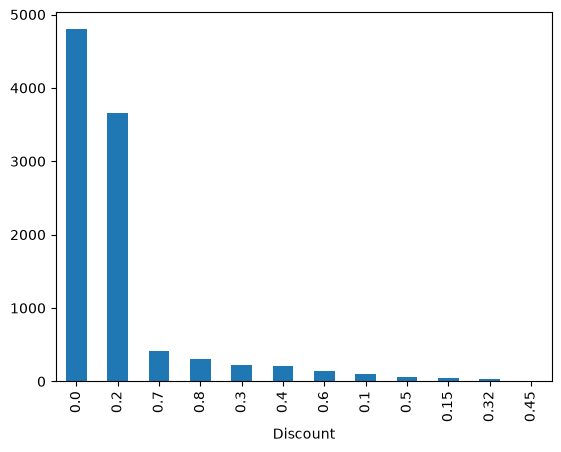

In [234]:
df_clean["Discount"].value_counts().plot(kind='bar')

In [235]:
df_clean["Discount Bucket"] = pd.cut(
    df_clean["Discount"],
    bins= [ -0.01, 0, 0.30, 0.6, 0.8, 1],
    labels= ["No Discount", "Low Discount", "Meduim Discount", "High Discount", "Extreme Discount"]
)
df_clean[["Discount", "Discount Bucket"]]

,Discount,Discount Bucket
0,0.00,No Discount
1,0.00,No Discount
2,0.00,No Discount
3,0.45,Meduim Discount
4,0.20,Low Discount
...,...,...
9988,0.20,Low Discount
9989,0.00,No Discount
9990,0.20,Low Discount
9991,0.00,No Discount


<Axes: xlabel='Discount Bucket'>

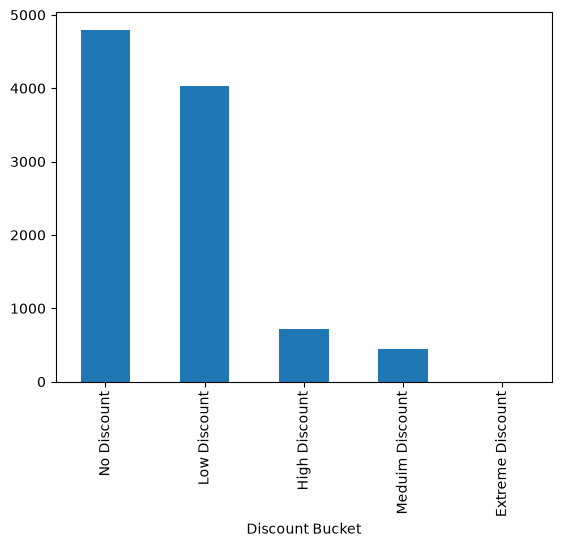

In [236]:
df_clean["Discount Bucket"].value_counts().plot(kind='bar')

In [237]:
df_clean.head(10)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Order Month,Shipping Days,Order Weekday,Order Quarter,Order Year,IS Weekend,Is Weekend,Unit Price,Profit Margin,Discount Bucket
0,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,November,3,Thursday,4,2018,False,False,130.9800,16.00,No Discount
1,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,November,3,Thursday,4,2018,False,False,243.9800,30.00,No Discount
2,Ca-2018-138688,2018-06-12,2018-06-16,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,June,4,Tuesday,2,2018,False,False,7.3100,47.00,No Discount
3,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,October,7,Wednesday,4,2017,False,False,191.5155,-40.00,Meduim Discount
4,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,October,7,Wednesday,4,2017,False,False,11.1840,11.25,Low Discount
5,Ca-2016-115812,2016-06-09,2016-06-14,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,June,5,Thursday,2,2016,False,False,6.9800,29.00,No Discount
6,Ca-2016-115812,2016-06-09,2016-06-14,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,June,5,Thursday,2,2016,False,False,1.8200,27.00,No Discount
7,Ca-2016-115812,2016-06-09,2016-06-14,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,June,5,Thursday,2,2016,False,False,151.1920,10.00,Low Discount
8,Ca-2016-115812,2016-06-09,2016-06-14,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,June,5,Thursday,2,2016,False,False,6.1680,31.25,Low Discount
9,Ca-2016-115812,2016-06-09,2016-06-14,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,June,5,Thursday,2,2016,False,False,22.9800,30.00,No Discount


In [238]:
df_clean["Discount"].max()

np.float64(0.8)

In [239]:

df_clean[["Sales", "Quantity", "Unit Price", "Profit", "Profit Margin", "Discount", "Discount Bucket"]].head()

,Sales,Quantity,Unit Price,Profit,Profit Margin,Discount,Discount Bucket
0,261.9600,2,130.9800,41.9136,16.00,0.00,No Discount
1,731.9400,3,243.9800,219.5820,30.00,0.00,No Discount
2,14.6200,2,7.3100,6.8714,47.00,0.00,No Discount
3,957.5775,5,191.5155,-383.0310,-40.00,0.45,Meduim Discount
4,22.3680,2,11.1840,2.5164,11.25,0.20,Low Discount


In [240]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order ID         9993 non-null   str           
 1   Order Date       9993 non-null   datetime64[us]
 2   Ship Date        9993 non-null   datetime64[us]
 3   Ship Mode        9993 non-null   category      
 4   Customer ID      9993 non-null   str           
 5   Customer Name    9993 non-null   str           
 6   Segment          9993 non-null   category      
 7   Country/Region   9993 non-null   category      
 8   City             9993 non-null   str           
 9   State            9993 non-null   category      
 10  Postal Code      9993 non-null   str           
 11  Region           9993 non-null   category      
 12  Product ID       9993 non-null   str           
 13  Category         9993 non-null   category      
 14  Sub-Category     9993 non-null   category      
 15

### Step 3 — Feature Engineering: Aggregated Features

Row-level features answer row-level questions. To answer "who are our most valuable customers?" (Q5) we need to roll individual order lines up to one row per entity:

- **Customer-level**: how often they order, how much they spend, how long they've been a customer
- **Product-level**: how much of each product sells, and at what average discount
- **RFM** (Recency / Frequency / Monetary): the classic customer-value framework, built directly from the two aggregates above plus `Order Date`

In [241]:
df_clean["IS Weekend"].value_counts()

IS Weekend
False    7257
True     2736
Name: count, dtype: int64

In [242]:
weekend_sales = df_clean.groupby(
    df_clean["IS Weekend"]
).agg(
    average_sales = ("Sales", "mean")
)
weekend_sales

,average_sales
IS Weekend,
False,229.787880
True,230.025163


In [243]:
df_clean.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Order Month,Shipping Days,Order Weekday,Order Quarter,Order Year,IS Weekend,Is Weekend,Unit Price,Profit Margin,Discount Bucket
0,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,November,3,Thursday,4,2018,False,False,130.9800,16.00,No Discount
1,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,November,3,Thursday,4,2018,False,False,243.9800,30.00,No Discount
2,Ca-2018-138688,2018-06-12,2018-06-16,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,June,4,Tuesday,2,2018,False,False,7.3100,47.00,No Discount
3,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,October,7,Wednesday,4,2017,False,False,191.5155,-40.00,Meduim Discount
4,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,October,7,Wednesday,4,2017,False,False,11.1840,11.25,Low Discount


In [244]:
customer_summary = df_clean.groupby(df_clean["Customer ID"]).agg(
    orders_count = ("Order ID", "nunique"),
    total_sales = ("Sales", "sum"),
    average_order_sales = ("Sales", "mean"),
    median_order_sales = ("Sales", "median"),
    first_order_date = ("Order Date", "min"),
    last_order_date = ("Order Date", "max")
)

customer_summary["Retention Days"] = (customer_summary["last_order_date"] - customer_summary["first_order_date"]).dt.days
customer_summary

,orders_count,total_sales,average_order_sales,median_order_sales,first_order_date,last_order_date,Retention Days
Customer ID,,,,,,,
Aa-10315,5,5563.560,505.778182,41.720,2016-03-31,2019-06-29,1185
Aa-10375,9,1056.390,70.426000,17.940,2016-04-21,2019-12-11,1329
Aa-10480,4,1790.512,149.209333,39.650,2016-05-04,2019-04-15,1076
Aa-10645,6,5086.935,282.607500,94.551,2016-06-22,2019-11-05,1231
Ab-10015,3,886.156,147.692667,135.346,2016-02-18,2018-11-10,996
...,...,...,...,...,...,...,...
Xp-21865,11,2374.658,84.809214,43.452,2016-01-20,2019-11-17,1397
Yc-21895,5,5454.350,681.793750,226.997,2016-11-17,2019-12-26,1134
Ys-21880,8,6720.444,560.037000,297.290,2017-01-12,2019-12-21,1073


In [245]:
df_clean["Customer ID"].value_counts()

Customer ID
Wb-21850    37
Ma-17560    34
Jl-15835    34
Pp-18955    34
Jd-15895    32
            ..
Jr-15700     1
Ao-10810     1
Ld-16855     1
Cj-11875     1
Re-19405     1
Name: count, Length: 793, dtype: int64

In [246]:
# Group the customer data.
customer_summary = df_clean.groupby(
    df_clean["Customer ID"]
).agg(
    total_sales = ("Sales", "sum"),
    average_sales = ("Sales", 'mean'),
    order_count = ("Order ID", "nunique"),
    total_profit = ("Profit", "sum"),
    average_discount = ("Discount", "mean")
)
customer_summary

,total_sales,average_sales,order_count,total_profit,average_discount
Customer ID,,,,,
Aa-10315,5563.560,505.778182,5,-362.8825,0.090909
Aa-10375,1056.390,70.426000,9,277.3824,0.080000
Aa-10480,1790.512,149.209333,4,435.8274,0.016667
Aa-10645,5086.935,282.607500,6,857.8033,0.063889
Ab-10015,886.156,147.692667,3,129.3465,0.066667
...,...,...,...,...,...
Xp-21865,2374.658,84.809214,11,621.2300,0.046429
Yc-21895,5454.350,681.793750,5,1305.6290,0.075000
Ys-21880,6720.444,560.037000,8,1778.2923,0.050000


In [247]:
df_clean["Region"].value_counts()

Region
West       3203
East       2847
Central    2323
South      1620
Name: count, dtype: int64

In [248]:
df_clean.groupby("Region").agg(
    Count_of_Orders = ("Order ID", "nunique"),
    Total_Sales = ("Sales", "sum")
)

,Count_of_Orders,Total_Sales
Region,,
Central,1175,501239.8908
East,1401,678499.8680
South,822,391721.9050
West,1611,725457.8245


In [249]:
df_clean["Discount Bucket"].value_counts()

Discount Bucket
No Discount         4798
Low Discount        4029
High Discount        718
Meduim Discount      448
Extreme Discount       0
Name: count, dtype: int64

In [250]:
# One row per customer: order count, spend, average order value, tenure
customer_features = df_clean.groupby("Customer ID", observed=True).agg(
    order_count=("Order ID", "nunique"),
    total_spend=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    avg_order_value=("Sales", "mean"),
    first_order=("Order Date", "min"),
    last_order=("Order Date", "max"),
)
customer_features.sort_values("Customer ID", ascending=True).head()

,order_count,total_spend,total_profit,avg_order_value,first_order,last_order
Customer ID,,,,,,
Aa-10315,5,5563.560,-362.8825,505.778182,2016-03-31,2019-06-29
Aa-10375,9,1056.390,277.3824,70.426000,2016-04-21,2019-12-11
Aa-10480,4,1790.512,435.8274,149.209333,2016-05-04,2019-04-15
Aa-10645,6,5086.935,857.8033,282.607500,2016-06-22,2019-11-05
Ab-10015,3,886.156,129.3465,147.692667,2016-02-18,2018-11-10


In [251]:
customer_features.info()

<class 'pandas.DataFrame'>
Index: 793 entries, Aa-10315 to Zd-21925
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_count      793 non-null    int64         
 1   total_spend      793 non-null    float64       
 2   total_profit     793 non-null    float64       
 3   avg_order_value  793 non-null    float64       
 4   first_order      793 non-null    datetime64[us]
 5   last_order       793 non-null    datetime64[us]
dtypes: datetime64[us](2), float64(3), int64(1)
memory usage: 49.7 KB


In [252]:
# Tenure = span between a customer's first and last order in this dataset
customer_features["Customer Tenure Days"] = (
    customer_features["last_order"] - customer_features["first_order"]
).dt.days

customer_features.sort_values("Customer Tenure Days", ascending=False).head(10)

,order_count,total_spend,total_profit,avg_order_value,first_order,last_order,Customer Tenure Days
Customer ID,,,,,,,
Mm-17920,11,3794.080,82.1250,237.130000,2016-01-13,2019-12-23,1440
Dl-13315,8,1458.258,288.8732,85.779882,2016-01-16,2019-12-08,1422
Cs-12250,12,2754.216,738.3626,98.364857,2016-01-13,2019-12-04,1421
Nd-18370,9,4326.139,353.6455,240.341056,2016-01-13,2019-12-03,1420
Ga-14725,11,1398.382,136.7079,63.562818,2016-02-11,2019-12-25,1413
Mv-17485,9,1560.050,189.0258,104.003333,2016-01-20,2019-12-03,1413
Me-17320,10,10663.728,1859.4695,484.714909,2016-01-06,2019-11-18,1412
Mv-18190,7,1734.574,273.8582,157.688545,2016-01-30,2019-12-11,1411
Bs-11590,6,2454.928,381.7807,245.492800,2016-01-14,2019-11-25,1411


In [253]:
# One row per product: units sold, revenue, average discount given
product_features = df_clean.groupby("Product ID", observed=True).agg(
    total_qty_sold=("Quantity", "sum"),
    total_revenue=("Sales", "sum"),
    avg_discount=("Discount", "mean"),
).sort_values("total_revenue", ascending=False)

product_features.head()

,total_qty_sold,total_revenue,avg_discount
Product ID,,,
Tec-Co-10004722,20,61599.824,0.12
Off-Bi-10003527,31,27453.384,0.24
Tec-Ma-10002412,6,22638.480,0.50
Fur-Ch-10002024,39,21870.576,0.20
Off-Bi-10001359,37,19823.479,0.30


In [254]:
df_clean.groupby("Customer ID").agg(
    last_order_date = ("Order Date", "max")
)

,last_order_date
Customer ID,
Aa-10315,2019-06-29
Aa-10375,2019-12-11
Aa-10480,2019-04-15
Aa-10645,2019-11-05
Ab-10015,2018-11-10
...,...
Xp-21865,2019-11-17
Yc-21895,2019-12-26
Ys-21880,2019-12-21


In [255]:
df_clean["Order Date"].min()

Timestamp('2016-01-03 00:00:00')

In [287]:
df_clean["Customer ID"].nunique()

793

In [301]:
# Recency
# Frequency
# Monetray

# RFM Model for Customer Segmentation

df_clean.groupby("Customer ID").agg(
    monetary_value = ("Sales", "sum"),
    frequency = ("Order ID", "nunique"),
    recency = ("Order Date", lambda x: (recency_reference - x.max()).days)
).sort_values("recency", ascending=True).head()

,monetary_value,frequency,recency
Customer ID,,,
Cc-12430,2870.050,10,1
Po-18865,2493.214,7,1
Jm-15580,303.948,5,1
Eb-13975,1643.255,4,1
Kb-16600,983.922,7,2


In [295]:
recency_reference = df_clean["Order Date"].max() + pd.Timedelta(days=1)
recency_reference

Timestamp('2019-12-31 00:00:00')

In [256]:
fixed_date = df_clean["Order Date"].max() + pd.Timedelta(days=1)
fixed_date

Timestamp('2019-12-31 00:00:00')

In [257]:
rfm_model_1 = df_clean.groupby("Customer ID").agg(
    monetary = ("Sales", "sum"),
    frequency = ("Order ID", "nunique"),
    recency = ("Order Date", lambda x: (fixed_date - x.max()).days)
)

rfm_model_1

,monetary,frequency,recency
Customer ID,,,
Aa-10315,5563.560,5,185
Aa-10375,1056.390,9,20
Aa-10480,1790.512,4,260
Aa-10645,5086.935,6,56
Ab-10015,886.156,3,416
...,...,...,...
Xp-21865,2374.658,11,44
Yc-21895,5454.350,5,5
Ys-21880,6720.444,8,10


In [258]:
reference_date = df_clean["Order Date"].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2019-12-31 00:00:00')

In [259]:
df_clean.head().sort_values("Order ID")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Order Month,Shipping Days,Order Weekday,Order Quarter,Order Year,IS Weekend,Is Weekend,Unit Price,Profit Margin,Discount Bucket
2,Ca-2018-138688,2018-06-12,2018-06-16,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,June,4,Tuesday,2,2018,False,False,7.3100,47.00,No Discount
0,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,November,3,Thursday,4,2018,False,False,130.9800,16.00,No Discount
1,Ca-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,November,3,Thursday,4,2018,False,False,243.9800,30.00,No Discount
3,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,October,7,Wednesday,4,2017,False,False,191.5155,-40.00,Meduim Discount
4,Us-2017-108966,2017-10-11,2017-10-18,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,October,7,Wednesday,4,2017,False,False,11.1840,11.25,Low Discount


In [260]:
# R - reference_date - last_order_date
# F - Unique count of Order ID for each customer
# M - Sum of Sales for each customer

rfm_model = df_clean.groupby("Customer ID").agg(
    recency = ("Order Date", lambda x: (reference_date - x.max()).days),
    frequency = ("Order ID", "nunique"),
    monetary = ("Sales", "sum")
)

rfm_model.sort_values("monetary", ascending=False)

,recency,frequency,monetary
Customer ID,,,
Sm-20320,80,5,25043.050
Tc-20980,400,5,19052.218
Rb-19360,97,6,15117.339
Ta-21385,70,4,14595.620
Ab-10105,42,10,14473.571
...,...,...,...
Rs-19870,20,2,22.328
Mg-18205,265,1,16.739
Cj-11875,366,1,16.520


In [261]:
# RFM: Recency (days since last order), Frequency (distinct orders),
# Monetary (total Sales). Recency is measured against the day after the
# last order in the whole dataset, since we have no "today" to measure from.
snapshot_date = df_clean["Order Date"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2019-12-31 00:00:00')

**In this part we are going to explain the Lambda function and how does it workin the context of rfm calculations.**

In [262]:
# # Explaining the lambda function
# list_test = [1,2,3,4,5]
# list_result = lambda x: x * 2 for x in list_test
# print(list_result)

In [263]:
# using the parameter observed=True should ensure that if we have empty category it will be shown with the zero value
rfm = df_clean.groupby("Customer ID", observed=True).agg(
    # how can we interpret the lambda thing?
    # lambda: this is the function name that we are going to create for this specific purpose
    # for each x in the order date for each customer id this x will equal to
    # the snapshot_date - the maximum order date and then we are going to calculate
    # the number of days between both dates
    Recency=("Order Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
)

rfm.sort_values("Monetary", ascending=False).head()

,Recency,Frequency,Monetary
Customer ID,,,
Sm-20320,80,5,25043.050
Tc-20980,400,5,19052.218
Rb-19360,97,6,15117.339
Ta-21385,70,4,14595.620
Ab-10105,42,10,14473.571


In [264]:
# This where we are going to calculate the last date in the dataset 
# We are goingt to add an extra day to fix the today date!
last_date = df_clean["Order Date"].max() + pd.Timedelta(days=1)
last_date

Timestamp('2019-12-31 00:00:00')

In [265]:
rfm_amended = df_clean.groupby("Customer ID").agg(
    recency = ("Order Date", lambda x: (last_date - x.max()).days),
    frequency = ("Order ID", "nunique"),
    monetary = ("Sales", "sum")
)

rfm_amended

,recency,frequency,monetary
Customer ID,,,
Aa-10315,185,5,5563.560
Aa-10375,20,9,1056.390
Aa-10480,260,4,1790.512
Aa-10645,56,6,5086.935
Ab-10015,416,3,886.156
...,...,...,...
Xp-21865,44,11,2374.658
Yc-21895,5,5,5454.350
Ys-21880,10,8,6720.444


### Step 4 — Feature Validation

New features can silently break things the raw columns never would: a ratio can divide by zero, a date subtraction can go negative if the source dates were wrong, a bin can leave rows unlabeled. Check every new feature once, right after creating it.

In [305]:
np.isinf(df_clean["Unit Price"]).sum()

np.int64(0)

In [303]:
df_clean["Sales"]/df_clean["Quantity"]

0       130.9800
1       243.9800
2         7.3100
3       191.5155
4        11.1840
          ...   
9988      8.4160
9989     45.9800
9990    129.2880
9991      7.4000
9992    121.5800
Length: 9993, dtype: float64

In [267]:
# Divide-by-zero / infinite values in the ratio features
print("Infinite Unit Price values:", np.isinf(df_clean["Unit Price"]).sum())
print("Infinite Profit Margin values:", np.isinf(df_clean["Profit Margin"]).sum())


Infinite Unit Price values: 0
Infinite Profit Margin values: 0


In [268]:
# Shipping Days should never be negative -- that would mean a product
# shipped before it was ordered
print("Shipping Days range:", df_clean["Shipping Days"].min(), "to", df_clean["Shipping Days"].max())
print("Negative Shipping Days:", (df_clean["Shipping Days"] < 0).sum())


Shipping Days range: 0 to 7
Negative Shipping Days: 0


In [269]:
# Every row should have landed in exactly one Discount Bucket
print("Unlabeled Discount Bucket rows:", df_clean["Discount Bucket"].isnull().sum())

Unlabeled Discount Bucket rows: 0


### Step 5 — Exploratory Data Analysis

Univariate first (what does one feature look like on its own), then bivariate (how does it relate to profit), then multivariate (multiple dimensions at once).

In [270]:
# Univariate: distribution of the new per-row features
print(df_clean["Discount Bucket"].value_counts())
print()
print(df_clean["Shipping Days"].describe())
print()
print(df_clean["Profit Margin"].describe())

Discount Bucket
No Discount         4798
Low Discount        4029
High Discount        718
Meduim Discount      448
Extreme Discount       0
Name: count, dtype: int64

count    9993.000000
mean        3.958071
std         1.748024
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

count    9993.000000
mean       12.033026
std        46.677485
min      -275.000000
25%         7.500000
50%        27.000000
75%        36.250000
max        50.000000
Name: Profit Margin, dtype: float64


In [307]:
df_clean["Discount Bucket"].value_counts()

Discount Bucket
No Discount         4798
Low Discount        4029
High Discount        718
Meduim Discount      448
Extreme Discount       0
Name: count, dtype: int64

In [311]:
# Bivariate: Profit against Discount Bucket, Sales against calendar features
print(df_clean.groupby("Discount Bucket")["Profit"].mean())
# print()
# print(df_clean.groupby("Order Month", observed=True)["Sales"].sum())

Discount Bucket
No Discount         66.900292
Low Discount        22.444342
Meduim Discount   -121.411568
High Discount      -98.348741
Name: Profit, dtype: float64


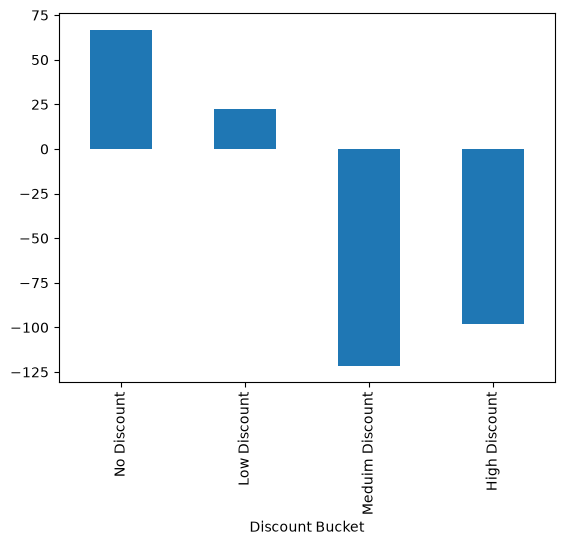

In [272]:
df_clean.groupby("Discount Bucket", observed=True)["Profit"].mean().plot(kind='bar')
plt.show()

(0.0, 367096.56198)

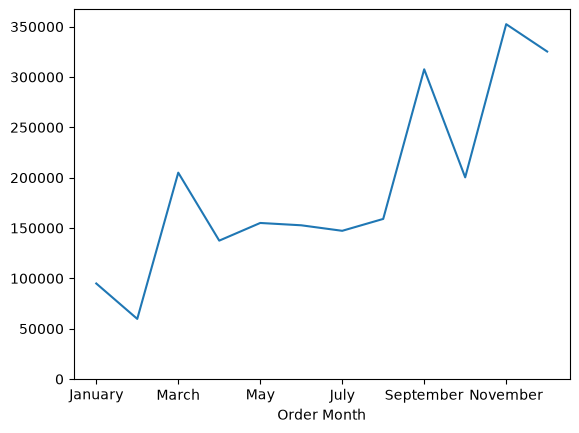

In [273]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
monthly_sales = df_clean.groupby("Order Month")["Sales"].sum()
monthly_sales.reindex(month_order).plot(kind='line')
plt.ylim(bottom=0)

**Multivariate**: once two dimensions aren't enough, `.groupby()` on multiple columns and `.pivot_table()` spread one categorical column across the columns of the result — closer to the shape a report or chart actually needs.

- `.groupby("column")` splits the DataFrame into groups sharing the same value; chaining an aggregation (`.sum()`, `.mean()`, `.agg()`) collapses each group into one row.
- `.pivot_table()` is the more flexible version — it lets a second categorical column spread across the result's columns.
- `.sort_values()` orders the result so the most/least interesting rows are easy to spot.

In [274]:
# Total profit and sales per Region, sorted from most to least profitable
region_summary = df_clean.groupby("Region", observed=True)[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)
region_summary

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678499.8680,91534.8388
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


In [275]:
# Multiple aggregations at once with .agg()
category_summary = df_clean.groupby("Category", observed=True).agg(
    total_sales=("Sales", "sum"),
    avg_profit=("Profit", "mean"),
    orders=("Order ID", "count"),
)
category_summary

,total_sales,avg_profit,orders
Category,,,
Furniture,741718.4233,8.709119,2120
Office Supplies,719047.0320,20.327050,6026
Technology,836154.0330,78.752002,1847


> I think before explaining this part we should start with what is the pivot table and how to build it using Python...

In [276]:
# pivot_table: average Sales by Region (rows) x Category (columns)
pivot = pd.pivot_table(
    df_clean,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="mean",
    observed=True,
)
pivot

Category,Furniture,Office Supplies,Technology
Region,,,
Central,340.534644,117.458801,405.753124
East,346.683053,120.044425,495.278469
South,353.309289,126.282727,507.753952
West,357.302325,116.422377,420.687533


### Step 6 — Answering the Questions

Back to the five questions from Step 1 — each one resolved directly with the features built above.

In [277]:
# Q1: which State generates the most Profit, and which the biggest loss?
state_profit = df_clean.groupby("State", observed=True)["Profit"].sum().sort_values(ascending=False)
print("Highest-profit state:", state_profit.idxmax(), "->", round(state_profit.max(), 2))
print("Biggest-loss state:", state_profit.idxmin(), "->", round(state_profit.min(), 2))
# state_profit

Highest-profit state: California -> 76381.39
Biggest-loss state: Texas -> -25729.36


<Axes: xlabel='Discount Bucket'>

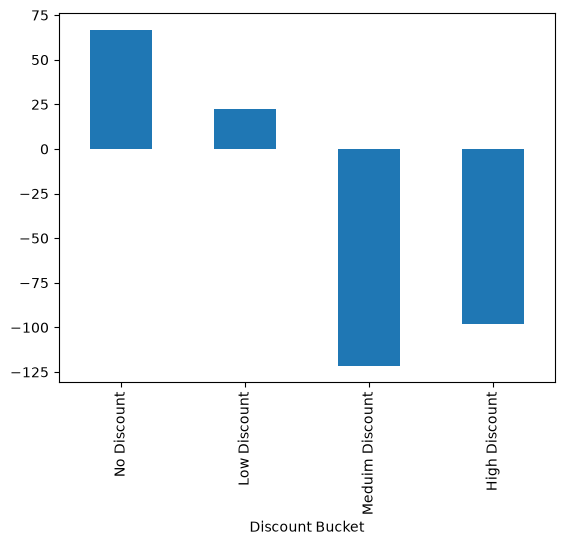

In [278]:
# Q2: relationship between Discount and Profit, using the bucket built in Step 2
discount_profit = df_clean.groupby("Discount Bucket", observed=True)["Profit"].mean()
discount_profit.plot(kind='bar')

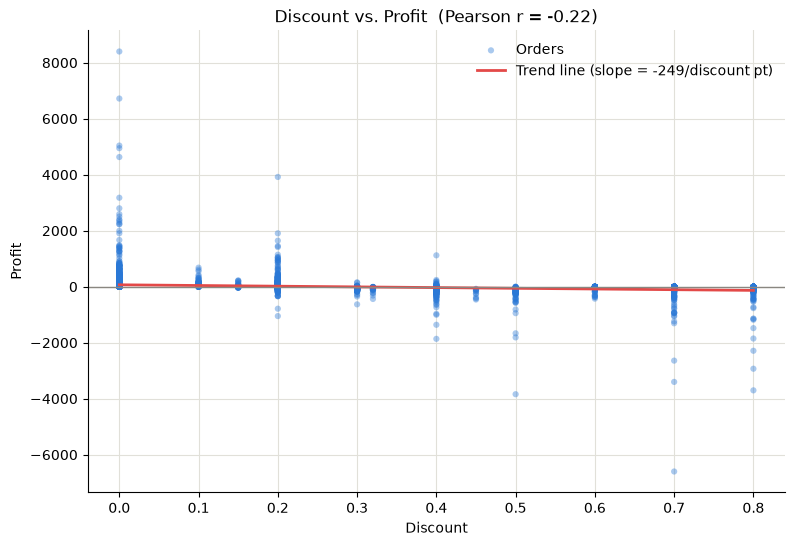

Pearson correlation (Discount, Profit): -0.219 -- a weak negative linear relationship.


In [279]:
# Here, I need to plot a scatter plot between the discount and the profit 
# Check the line between both of them

correlation = df_clean["Discount"].corr(df_clean["Profit"])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    df_clean["Discount"], df_clean["Profit"],
    color="#2a78d6", alpha=0.4, s=20, edgecolors="none", label="Orders",
)

trend_coeffs = np.polyfit(df_clean["Discount"], df_clean["Profit"], deg=1)
trend_line = np.poly1d(trend_coeffs)
x_trend = np.linspace(df_clean["Discount"].min(), df_clean["Discount"].max(), 100)
ax.plot(
    x_trend, trend_line(x_trend),
    color="#e34948", linewidth=2, label=f"Trend line (slope = {trend_coeffs[0]:.0f}/discount pt)",
)

ax.axhline(0, color="#898781", linewidth=1)
ax.set_xlabel("Discount")
ax.set_ylabel("Profit")
ax.set_title(f"Discount vs. Profit  (Pearson r = {correlation:.2f})")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.show()

strength = (
    "strong" if abs(correlation) >= 0.5 else
    "moderate" if abs(correlation) >= 0.3 else
    "weak" if abs(correlation) >= 0.1 else
    "negligible"
)
direction = "negative" if correlation < 0 else "positive"
print(f"Pearson correlation (Discount, Profit): {correlation:.3f} -- a {strength} {direction} linear relationship.")

In [280]:
# Q3: does Ship Mode relate to profitability or shipping time?
ship_mode_summary = df_clean.groupby("Ship Mode", observed=True).agg(
    avg_profit=("Profit", "mean"),
    avg_shipping_days=("Shipping Days", "mean"),
)
ship_mode_summary
# ship_mode_summary.plot(kind='line')

,avg_profit,avg_shipping_days
Ship Mode,,
First Class,31.839948,2.182705
Same Day,29.266591,0.044199
Second Class,29.535545,3.237532
Standard Class,27.501399,5.006704


(0.0, 367096.56198)

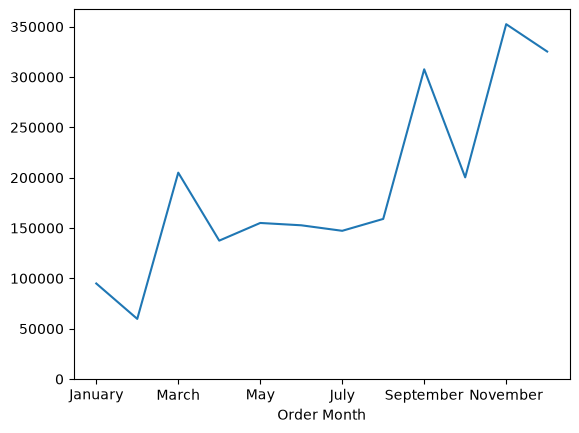

In [281]:
# Q4: seasonality in Sales -- by month and by weekday
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_clean.groupby("Order Month", observed=True)["Sales"].sum().reindex(month_order).plot(kind='line')
plt.ylim(bottom=0)


(0.0, 405465.006295)

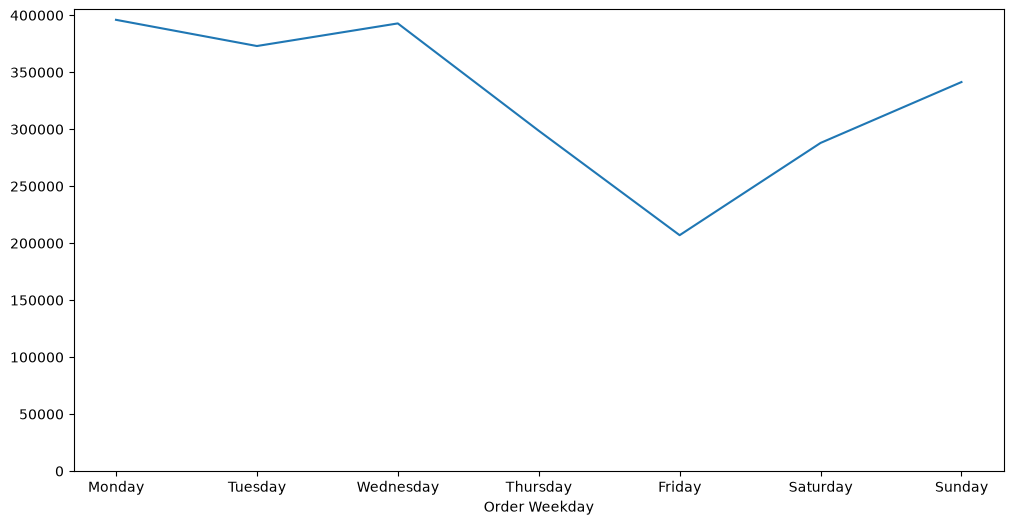

In [282]:
df_clean.groupby("Order Weekday", observed=True)["Sales"].sum().sort_values(ascending=False).reindex(week_order).plot(kind='line', figsize=(12,6))
plt.ylim(bottom=0)

In [283]:
# Q5: most valuable customers, using the RFM features from Step 3
rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary
Customer ID,,,
Sm-20320,80,5,25043.050
Tc-20980,400,5,19052.218
Rb-19360,97,6,15117.339
Ta-21385,70,4,14595.620
Ab-10105,42,10,14473.571
Kl-16645,48,12,14175.229
Sc-20095,350,9,14142.334
Hl-15040,44,6,12873.298
Se-20110,10,11,12209.438


### Try It Yourself

1. Group by `Sub-Category` and find total `Profit`, sorted ascending (most loss-making first) — which sub-category loses the most money overall?
2. Build a pivot table showing total `Sales` with `Segment` as rows and `Ship Mode` as columns.
3. Using `.groupby()` with `.agg()`, compute both the average and the maximum `Shipping Days` per `Ship Mode`.

In [284]:
# TODO 1: total Profit per Sub-Category, sorted ascending


# TODO 2: pivot table -- Sales by Segment (rows) x Ship Mode (columns)


# TODO 3: average and max Shipping Days per Ship Mode

### Step 7 — Insight Synthesis

- **Profit by state**: California is the strongest performer (~$76.4K total profit); Texas is the biggest drag (~-$25.7K total loss) — worth checking whether that's driven by discounting practices specific to Texas.
- **Discount vs. Profit**: a clear, monotonic relationship. Average profit per order falls as the discount band rises — roughly +$67 with no discount, +$27 at Low, **-$78 at Medium, -$107 at High**. Discounts above ~20% are, on average, selling at a loss.
- **Ship Mode**: shipping time behaves exactly as expected (Same Day ≈ 0 days, Standard Class ≈ 5 days), but average profit per order is fairly flat across all four modes (~$28–32) — shipping choice doesn't appear to drive profitability on its own.
- **Seasonality**: Sales rise sharply toward year-end (November and December are the two highest months, roughly 3–4x February's total), consistent with holiday retail patterns. By weekday, Monday/Tuesday/Wednesday outsell Friday by close to 2x.
- **Customer value**: spend is concentrated — the top RFM customer alone accounts for ~$25K in lifetime Sales, well above the ~$2.9K average, suggesting a small set of high-value accounts worth treating differently from the broader base.

**Caveat carried from cleaning:** these Profit/Sales totals reflect the decision *not* to collapse the 7 legitimate `Order ID` + `Product ID` duplicate pairs — collapsing them would have understated every total above.

### Step 8 — Handoff Prep for Visualization

The next stage (lectures 7–8) turns these tables into charts. This notebook's job is to make sure nothing needs recomputing there — everything it needs already exists, by name, above.

In [285]:
# Tables and features the visualization stage will need -- named here so
# nothing has to be recomputed in the next notebook.
handoff_manifest = {
    "df_clean": "row-level cleaned + feature-engineered DataFrame",
    "customer_features": "one row per Customer ID -- spend, order count, tenure",
    "product_features": "one row per Product ID -- units sold, revenue, avg discount",
    "rfm": "one row per Customer ID -- Recency, Frequency, Monetary",
    "state_profit": "total Profit per State",
    "discount_profit": "average Profit per Discount Bucket",
    "ship_mode_summary": "average Profit and Shipping Days per Ship Mode",
    "region_summary": "total Sales and Profit per Region",
    "category_summary": "total Sales, avg Profit, order count per Category",
    "pivot": "average Sales by Region x Category",
}
for name, description in handoff_manifest.items():
    print(f"{name}: {description}")

df_clean: row-level cleaned + feature-engineered DataFrame
customer_features: one row per Customer ID -- spend, order count, tenure
product_features: one row per Product ID -- units sold, revenue, avg discount
rfm: one row per Customer ID -- Recency, Frequency, Monetary
state_profit: total Profit per State
discount_profit: average Profit per Discount Bucket
ship_mode_summary: average Profit and Shipping Days per Ship Mode
region_summary: total Sales and Profit per Region
category_summary: total Sales, avg Profit, order count per Category
pivot: average Sales by Region x Category


### Step 9 — Persist Handoff Tables to Disk

Listing the tables above isn't enough on its own -- `visualization_dashboard.ipynb` runs its **own kernel** and has no access to the variables sitting in this one's memory. Every object named in `handoff_manifest` gets written to a `handoff_data/` folder here, and the visualization notebook's Step 0 reads them straight back in.

- **Parquet** for the row-level / per-entity tables (`df_clean`, `customer_features`, `product_features`, `rfm`) -- preserves dtypes (`datetime64`, `category`) exactly like the clean-data handoff from the cleaning notebook.
- **CSV** for the small summary tables (`state_profit`, `discount_profit`, `ship_mode_summary`, `region_summary`, `category_summary`, `pivot`) -- they're already chart-ready and don't carry dtypes worth preserving via Parquet.

In [312]:
customer_features

,order_count,total_spend,total_profit,avg_order_value,first_order,last_order,Customer Tenure Days
Customer ID,,,,,,,
Aa-10315,5,5563.560,-362.8825,505.778182,2016-03-31,2019-06-29,1185
Aa-10375,9,1056.390,277.3824,70.426000,2016-04-21,2019-12-11,1329
Aa-10480,4,1790.512,435.8274,149.209333,2016-05-04,2019-04-15,1076
Aa-10645,6,5086.935,857.8033,282.607500,2016-06-22,2019-11-05,1231
Ab-10015,3,886.156,129.3465,147.692667,2016-02-18,2018-11-10,996
...,...,...,...,...,...,...,...
Xp-21865,11,2374.658,621.2300,84.809214,2016-01-20,2019-11-17,1397
Yc-21895,5,5454.350,1305.6290,681.793750,2016-11-17,2019-12-26,1134
Ys-21880,8,6720.444,1778.2923,560.037000,2017-01-12,2019-12-21,1073


In [313]:
product_features

,total_qty_sold,total_revenue,avg_discount
Product ID,,,
Tec-Co-10004722,20,61599.824,0.12
Off-Bi-10003527,31,27453.384,0.24
Tec-Ma-10002412,6,22638.480,0.50
Fur-Ch-10002024,39,21870.576,0.20
Off-Bi-10001359,37,19823.479,0.30
...,...,...,...
Off-Ar-10003986,2,7.700,0.00
Off-En-10001535,2,7.072,0.20
Off-Pa-10000048,1,6.480,0.00


In [314]:
rfm

,Recency,Frequency,Monetary
Customer ID,,,
Aa-10315,185,5,5563.560
Aa-10375,20,9,1056.390
Aa-10480,260,4,1790.512
Aa-10645,56,6,5086.935
Ab-10015,416,3,886.156
...,...,...,...
Xp-21865,44,11,2374.658
Yc-21895,5,5,5454.350
Ys-21880,10,8,6720.444


In [316]:
import os

export_dir = "handoff_data"
os.makedirs(export_dir, exist_ok=True)

# Row-level / per-entity tables -- Parquet preserves dtypes
df_clean.to_parquet(f"{export_dir}/df_clean.parquet", engine="pyarrow")
customer_features.to_parquet(f"{export_dir}/customer_features.parquet", engine="pyarrow")
product_features.to_parquet(f"{export_dir}/product_features.parquet", engine="pyarrow")
rfm.to_parquet(f"{export_dir}/rfm.parquet", engine="pyarrow")

# Small, chart-ready summary tables -- CSV is sufficient
state_profit.to_csv(f"{export_dir}/state_profit.csv")
discount_profit.to_csv(f"{export_dir}/discount_profit.csv")
ship_mode_summary.to_csv(f"{export_dir}/ship_mode_summary.csv")
region_summary.to_csv(f"{export_dir}/region_summary.csv")
category_summary.to_csv(f"{export_dir}/category_summary.csv")
pivot.to_csv(f"{export_dir}/pivot_region_category.csv")

print(f"Exported {len(os.listdir(export_dir))} files to '{export_dir}/':")
for filename in sorted(os.listdir(export_dir)):
    print(f"  {filename}")

Exported 10 files to 'handoff_data/':
  category_summary.csv
  customer_features.parquet
  df_clean.parquet
  discount_profit.csv
  pivot_region_category.csv
  product_features.parquet
  region_summary.csv
  rfm.parquet
  ship_mode_summary.csv
  state_profit.csv


In [315]:
state_profit

State
California              76381.3871
New York                74038.5486
Washington              33402.6517
Michigan                24463.1876
Virginia                18597.9504
Indiana                 18382.9363
Georgia                 16250.0433
Kentucky                11199.6966
Minnesota               10823.1874
Delaware                 9977.3748
New Jersey               9772.9138
Wisconsin                8401.8004
Rhode Island             7285.6293
Maryland                 7031.1788
Massachusetts            6785.5016
Missouri                 6436.2105
Alabama                  5786.8253
Oklahoma                 4853.9560
Arkansas                 4008.6871
Connecticut              3511.4918
Nevada                   3316.7659
Mississippi              3172.9762
Utah                     2546.5335
Vermont                  2244.9783
Louisiana                2196.1023
Nebraska                 2037.0942
Montana                  1833.3285
South Carolina           1769.0566
New Hampshire 